# Logistic regression regression with gradient descent

In [1]:
import numpy as np
import matplotlib.pyplot as plt

X shape: (100, 2)  y shape: (100,)


Text(0, 0.5, 'x2')

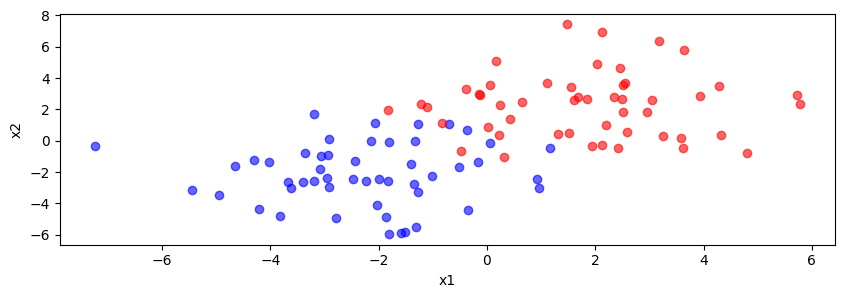

In [2]:
# In the following, the function `generate_data()` generates a 2-class and 2-dimensional dataset.

np.random.seed(42)

def generate_data(mu1=(-2, -2), mu2=(2, 2), s1=2, s2=2, N=100):
    X = np.vstack([
        np.random.normal(loc=mu1, scale=s1, size=(N//2, 2)), 
        np.random.normal(loc=mu2, scale=s2, size=(N//2, 2))
    ])
    y = np.hstack([
        np.zeros(N//2), 
        np.ones(N//2),
    ])
    idx = np.random.permutation(N)
    X = X[idx, :]
    y = y[idx]
    return X, y

N = 100
X, y = generate_data(N=100)
print("X shape:", X.shape, " y shape:", y.shape)

plt.figure(figsize=(10, 3))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c="b", label="class 0", alpha=0.6)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c="r", label="class 1", alpha=0.6)
plt.xlabel("x1")
plt.ylabel("x2")

## Exercise 1: Augmented dataset
We can make our life a bit easier if we use the augmented notation. That is, we define the bias as a feature that is always there with the same amplitude (i.e., always 1). Typically, this bias feature is added as the first feature. Then, automatically, our first weight $w_0$ will be the bias term. 
1. Add a column full of ones to the dataset

In [3]:
X = np.insert(X, 0, 1, axis=1)

## Exercise 2: The sigmoid function
The sigmoid function is important for logistic regression. It takes the form $z=f(x)=(1+exp(-x))^{-1}$.
1. Implement the function `sigmoid(x)` that takes an input `x` and returns the output of the sigmoid `z`.
2. Plot the function over some range of values to verify it is implemented correctly.

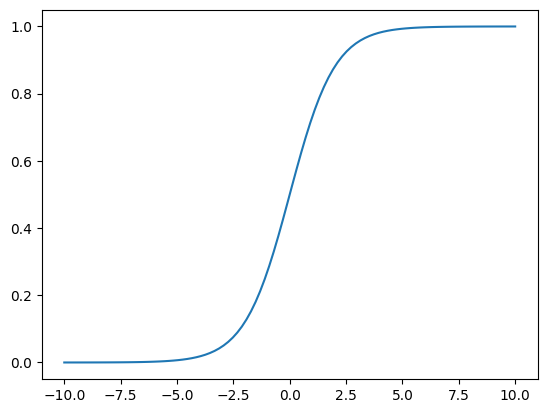

In [39]:
def sigmoid(x: np.ndarray) -> float:
    return np.power(1+np.exp(-x), -1)
    

x = np.linspace(-10, 10, 100)
plt.plot(x, sigmoid(x))

## Exercise 3: Logistic regression
In non-augmented form, the decision function of logistic regression is $p = f(\mathbf{w}^\top\mathbf{x})+b$, with $f(.)$ the sigmoid. In augmented form, this reduces to $p = f(\mathbf{w}^\top\mathbf{x})$, as the bias is incorporated in $\mathbf{w}$ and the data is augmented. 
1. Implement the function `logistic_regression(X, w)` that receives data `X` and applies the weights `w` and the sigmoid. 

In [38]:
def logistic_regression(X: np.ndarray, w: np.ndarray) -> np.ndarray:
    return sigmoid(X @ w)

## Exercise 4: Cross-entropy loss function
Logistic regression optimized the cross-entropy loss function:
$$L(X,w) = -\sum^N \mathbf{y}\log(\mathbf{p}) + (1 - \mathbf{y})\log(1-\mathbf{p})$$
Here, again, $p=f(\mathbf{w}^\top\mathbf{X})$.
1. Implement the function `cross_entropy(X, y, w)` that receives the data `X`, labels `y` and weights `w`, and computes the corss-entropy loss.

In [36]:
def cross_entropy(X, y, w):
    p = logistic_regression(X, w)
    return -np.sum(y * np.log(p) + (1-y) * np.log(1-p))

## Exercise 5: The gradient
The partial derivative of the cross-entropy loss function with respect to the weights goes as follows:
$$\frac{\delta L}{\delta w_j} = -\frac{1}{N} \sum^N_i \frac{\delta L}{\delta p_i}\frac{\delta p_i}{\delta z_i}\frac{\delta z_i}{\delta w_j}
=-\frac{1}{N} \sum^N_i (\frac{y_i}{p_i}-\frac{1-y_i}{1-p_i})(p_i(1-p_i))x_{ij}$$
$$=-\frac{1}{N} \sum^N_i (y_i(1-p_i)-(1-y_i)p_i)x_{ij}
=-\frac{1}{N} \sum^N_i(y_i-p_i)x_{ij}
=\frac{1}{N} \sum^N_i(p_i-y_i)x_{ij}$$
1. Implement the function `gradient(X, y, w)` that computes this gradient.

In [35]:
def gradient(X, y, w):
    p = logistic_regression(X, w)
    return np.divide((p - y) @ x.T, len(X))

## Exercise 6: Gradient descent
Gradient descent is an iterative scheme that updates the weights at every iteration as follows:
$$w_j^t = w_j^{t-1} - \alpha \frac{\delta L}{\delta w_j}$$
Here, $\alpha$ is the learning rate.
1. Implement the function `gradient_descent(X, y, alpha, n_iter)` that does the following:
   1. Assign random values to the initial weight vector.
   2. Loop over iterations: for each, compute the gradient and update the weights.
1. The function should output the learned weights, as well as the loss at each iteration.

In [46]:
from functools import reduce, partial
from itertools import accumulate


def gradient_descent(X, y, alpha, n_iter):
    def step(state, _):
        w, _loss = state
        w_new = w - alpha * gradient(X, y, w)
        return w_new, cross_entropy(X, y, w_new)

    w0 = np.random.rand(X.shape[1])
    states = list(accumulate(range(n_iter), step, initial=(w0, cross_entropy(X, y, w0))))
    weights, losses = zip(*states)
    return weights[-1], losses


## Exercise 7: Learn a logistic regression model
1. Learn the logistic regression model using the dataset.
2. Visualize the data and the learned decision boundary (where $\mathbf{w}^\top\mathbf{X}=0$).
3. Visualize the loss across iterations.

/tmp/nix-shell.qdv4cb/ipykernel_51398/2991324591.py:3: RuntimeWarning: divide by zero encountered in log
  return -np.sum(y * np.log(p) + (1-y) * np.log(1-p))


[]

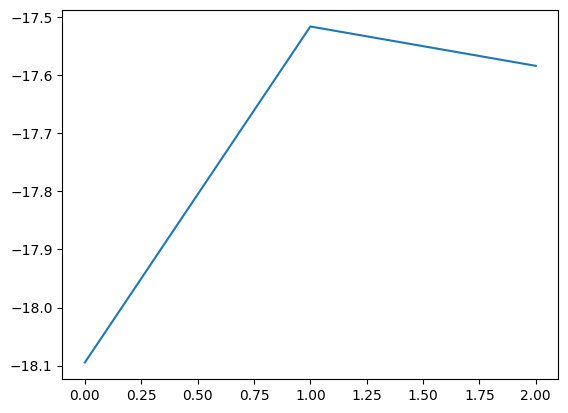

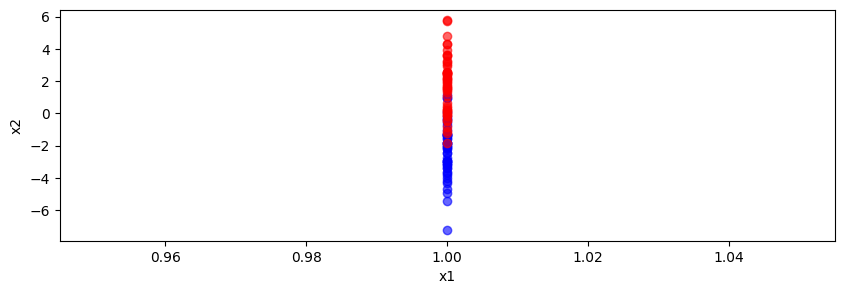

In [49]:
losses, weights = gradient_descent(X, y, 0.1, 200)

plt.plot(losses)

plt.figure(figsize=(10, 3))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c="b", label="class 0", alpha=0.6)
plt.scatter(X[y == 1, 0], X[y == 1, 1], c="r", label="class 1", alpha=0.6)
plt.xlabel("x1")
plt.ylabel("x2")

plt.plot()

## Exercise 8: Apply a logistic regression model
1. Apply the learned logistic regression function to the dataset.
2. The model returns a probability; how do you convert these to class labels? Convert the probability $p$ into predicted class labels $\hat{y}$.
3. Compute the accuracy of the model.

In [ ]:
# Answer here